**По варианту**

1. Построить нейросетевой классификатор типа: простая рекуррентная сеть
2. Построить полносвязную нейронную сеть, позволяющую решить поставленную задачу классификации (пример см. в лекциях). Для улучшения качества обучения и валидации использовать методы: предварительно обученных векторных представлений слов Word2vecно обученных векторных представле
ы:етрик и ошибок.

In [1]:
from keras.datasets import imdb
from sklearn.model_selection import train_test_split

(train_data, train_labels), (test_data, test_labels) = imdb.load_data()
val_data, test_data, val_labels, test_labels = train_test_split(test_data, test_labels, test_size=0.2, random_state=42)
print(f"Размер тренировочного набора: {len(train_data)}")
print(f"Размер валидационного набора: {len(val_data)}")
print(f"Размер тестового набора: {len(test_data)}")

print(train_data[1])

Размер тренировочного набора: 25000
Размер валидационного набора: 20000
Размер тестового набора: 5000
[1, 194, 1153, 194, 8255, 78, 228, 5, 6, 1463, 4369, 5012, 134, 26, 4, 715, 8, 118, 1634, 14, 394, 20, 13, 119, 954, 189, 102, 5, 207, 110, 3103, 21, 14, 69, 188, 8, 30, 23, 7, 4, 249, 126, 93, 4, 114, 9, 2300, 1523, 5, 647, 4, 116, 9, 35, 8163, 4, 229, 9, 340, 1322, 4, 118, 9, 4, 130, 4901, 19, 4, 1002, 5, 89, 29, 952, 46, 37, 4, 455, 9, 45, 43, 38, 1543, 1905, 398, 4, 1649, 26, 6853, 5, 163, 11, 3215, 10156, 4, 1153, 9, 194, 775, 7, 8255, 11596, 349, 2637, 148, 605, 15358, 8003, 15, 123, 125, 68, 23141, 6853, 15, 349, 165, 4362, 98, 5, 4, 228, 9, 43, 36893, 1157, 15, 299, 120, 5, 120, 174, 11, 220, 175, 136, 50, 9, 4373, 228, 8255, 5, 25249, 656, 245, 2350, 5, 4, 9837, 131, 152, 491, 18, 46151, 32, 7464, 1212, 14, 9, 6, 371, 78, 22, 625, 64, 1382, 9, 8, 168, 145, 23, 4, 1690, 15, 16, 4, 1355, 5, 28, 6, 52, 154, 462, 33, 89, 78, 285, 16, 145, 95]


In [246]:
# Получение словаря индексов
word_index = imdb.get_word_index()

# Инвертируем словарь: индексы -> слова
reverse_word_index = {value: key for key, value in word_index.items()}

# Декодируем отзыв
decoded_review = " ".join([reverse_word_index.get(i - 3, "?") for i in train_data[1]])
print(decoded_review)

? big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i've seen hundreds but this had got to be on of the worst ever made the plot is paper thin and ridiculous the acting is an abomination the script is completely laughable the best is the end showdown with the cop and how he worked out who the killer is it's just so damn terribly written the clothes are sickening and funny in equal measures the hair is big lots of boobs bounce men wear those cut tee shirts that show off their stomachs sickening that men actually wore them and the music is just synthesiser trash that plays over and over again in almost every scene there is trashy music boobs and paramedics taking away bodies and the gym still doesn't close for bereavement all joking aside this is a truly bad film whose only charm is to look back on the disaster that was the 80's and have a good old laugh at how bad everything was back then


In [247]:
print(train_labels[1])

0


In [3]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.neural_network import BernoulliRBM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, Embedding, SimpleRNN
import tensorflow as tf
import numpy as np

maxlen = 400
max_features = 10000

Так как встроенной метрики F1 нет, создадим её

In [5]:
def f1_score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)  # Приводим y_true к типу float32
    tp = tf.reduce_sum(tf.cast(y_true * y_pred, tf.float32))  # True Positives
    fp = tf.reduce_sum(tf.cast((1 - y_true) * y_pred, tf.float32))  # False Positives
    fn = tf.reduce_sum(tf.cast(y_true * (1 - y_pred), tf.float32))  # False Negatives

    precision = tp / (tp + fp + tf.keras.backend.epsilon())
    recall = tp / (tp + fn + tf.keras.backend.epsilon())

    f1 = 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())
    return f1

Простая рекурентная сеть (по варианту)

In [252]:

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words = max_features)
val_data, test_data, val_labels, test_labels = train_test_split(test_data, test_labels, test_size=0.2, random_state=42)
train_data = pad_sequences(train_data, maxlen=maxlen)
test_data = pad_sequences(test_data, maxlen=maxlen)
val_data = pad_sequences(val_data, maxlen=maxlen)
# Строим модель
model = Sequential()
model.add(Embedding(max_features, 32))
model.add(Dropout(0.5))
model.add(SimpleRNN(16)) # Простая рекуррентная сеть
model.add(Dense(1, activation='sigmoid'))

# Компиляция модели
model.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy', f1_score])
history = model.fit(train_data, train_labels, epochs=7, batch_size=32, validation_data=(val_data, val_labels))

Epoch 1/7
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.5566 - f1_score: 0.4958 - loss: 0.6709 - val_accuracy: 0.8181 - val_f1_score: 0.5194 - val_loss: 0.4190
Epoch 2/7
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.8228 - f1_score: 0.4980 - loss: 0.4062 - val_accuracy: 0.7396 - val_f1_score: 0.3799 - val_loss: 0.6115
Epoch 3/7
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.8549 - f1_score: 0.4920 - loss: 0.3454 - val_accuracy: 0.7818 - val_f1_score: 0.5609 - val_loss: 0.5871
Epoch 4/7
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.8670 - f1_score: 0.5081 - loss: 0.3389 - val_accuracy: 0.8475 - val_f1_score: 0.4761 - val_loss: 0.3448
Epoch 5/7
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.8914 - f1_score: 0.4897 - loss: 0.2819 - val_accuracy: 0.8573 - val_f1_score: 0.5139 - val_loss: 0.3235
Epoch 6/7
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.8986 - f1_score: 0.4989 - loss: 0.2602 - val_accuracy: 0.8745 - val_f1_score: 

In [253]:
test = "this was painfully disappointing. expected much more"
test = test.split()
for i in range(len(test)):
    if test[i] in word_index:
        test[i] = word_index[test[i]]+3
    else:
        test[i] = 1
    if test[i]>10000:
        test[i] = 1

test = np.array(test)
desired_length = 400
padded_test = np.pad(test, (desired_length - len(test), 0), 'constant')
padded_test = padded_test.reshape(1, 400) 
print(model.predict(padded_test))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
[[0.03969235]]


Посмотрим графики метрики и функции потерь для простой рекурентной сети

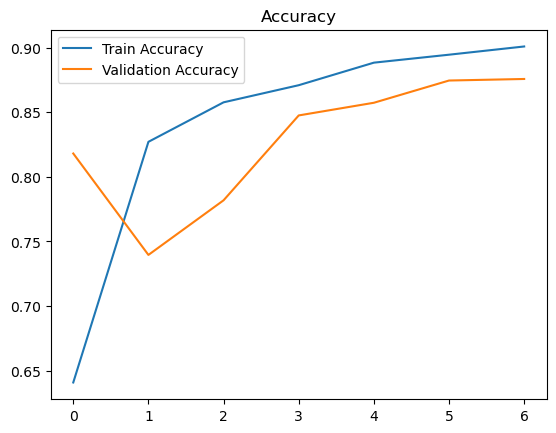

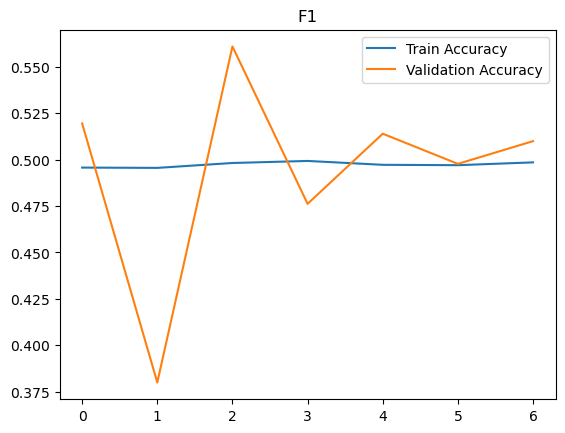

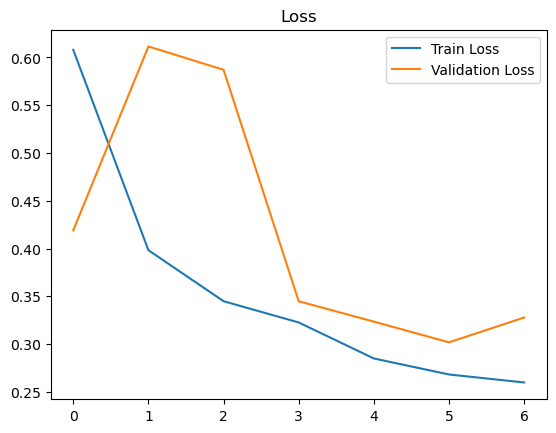

In [255]:
import matplotlib.pyplot as plt

# График accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

# График f1
plt.plot(history.history['f1_score'], label='Train Accuracy')
plt.plot(history.history['val_f1_score'], label='Validation Accuracy')
plt.legend()
plt.title('F1')
plt.show()

# График потерь
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

Проведем испытание на тестовой выборке

In [257]:
# Оценка модели на тестовых данных
test_loss, test_accuracy, test_f1 = model.evaluate(test_data, test_labels)

# Вывод результатов
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")
print(f"Test F1 Score: {test_f1}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8809 - f1_score: 0.5083 - loss: 0.3193
Test Loss: 0.32115164399147034
Test Accuracy: 0.8784000277519226
Test F1 Score: 0.5098179578781128


Полносвязная сеть

In [259]:
model_fc = Sequential()
model_fc.add(Embedding(max_features, 32))
model_fc.add(Flatten())
model_fc.add(Dropout(0.5))
model_fc.add(Dense(32, activation='relu'))
model_fc.add(Dense(16, activation='relu'))
model_fc.add(Dense(1, activation='sigmoid')) # Выходной слой для бинарной классификации
model_fc.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy', f1_score])
history_fcn = model_fc.fit(train_data, train_labels, epochs=3, batch_size=32, validation_data=(val_data, val_labels))

Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6383 - f1_score: 0.4993 - loss: 0.6021 - val_accuracy: 0.7811 - val_f1_score: 0.3986 - val_loss: 0.4591
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8976 - f1_score: 0.4971 - loss: 0.2528 - val_accuracy: 0.8692 - val_f1_score: 0.4937 - val_loss: 0.3016
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9396 - f1_score: 0.5003 - loss: 0.1607 - val_accuracy: 0.8772 - val_f1_score: 0.5041 - val_loss: 0.3171


In [260]:
test = "this was painfully disappointing. expected much more"
test = test.split()
for i in range(len(test)):
    if test[i] in word_index:
        test[i] = word_index[test[i]]+3
    else:
        test[i] = 1
    if test[i]>10000:
        test[i] = 1

test = np.array(test)
#print(test)
desired_length = 400
padded_test = np.pad(test, (desired_length - len(test), 0), 'constant')
#print(padded_test) 
#print(word_index)
padded_test = padded_test.reshape(1, 400) 
print(model_fc.predict(padded_test))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
[[0.04463348]]


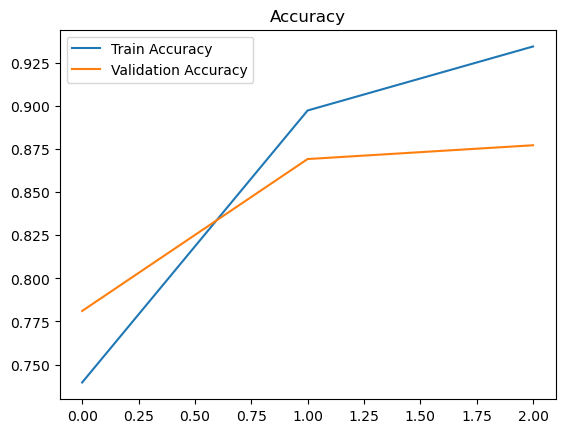

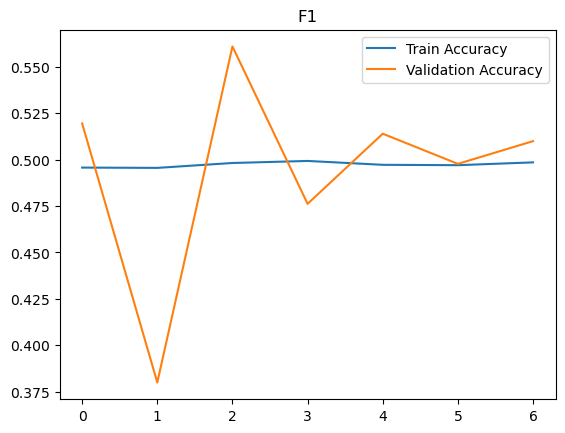

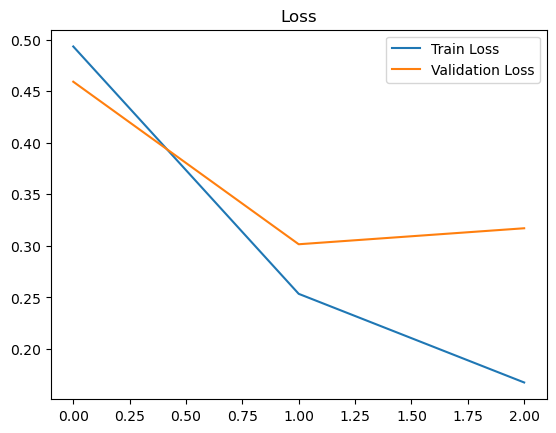

In [261]:
import matplotlib.pyplot as plt

# График точности
plt.plot(history_fcn.history['accuracy'], label='Train Accuracy')
plt.plot(history_fcn.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

# График f1
plt.plot(history.history['f1_score'], label='Train Accuracy')
plt.plot(history.history['val_f1_score'], label='Validation Accuracy')
plt.legend()
plt.title('F1')
plt.show()

# График потерь
plt.plot(history_fcn.history['loss'], label='Train Loss')
plt.plot(history_fcn.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

In [262]:
# Оценка модели на тестовых данных
test_loss, test_accuracy, test_f1 = model.evaluate(test_data, test_labels)

# Вывод результатов
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")
print(f"Test F1 Score: {test_f1}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8809 - f1_score: 0.5083 - loss: 0.3193
Test Loss: 0.32115164399147034
Test Accuracy: 0.8784000277519226
Test F1 Score: 0.5098179578781128


In [131]:
from gensim.models import KeyedVectors
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer

# Загрузка Word2Vec
model_path = 'C:/Users/Александр/Desktop/GoogleNews-vectors-negative300.bin/GoogleNews-vectors-negative300.bin'
word2vec_model = KeyedVectors.load_word2vec_format(model_path, binary=True)


In [145]:
# Размерность векторов
embedding_dim = word2vec_model.vector_size

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words = max_features)
train_data = [[word - 3 for word in review] for review in train_data]
test_data = [[word - 3 for word in review] for review in test_data]
# Получение маппинга из индексов в слова
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

# Преобразование индексов в слова
decoded_reviews = [
    [reverse_word_index.get(i, "?") for i in review]
    for review in train_data
]

# Пример текстов
texts = decoded_reviews

# Токенизация текста
tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)
word_index = tokenizer.word_index

# Создание матрицы эмбеддингов
vocab_size = len(word_index) + 1
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():
    if word in word2vec_model:
        embedding_matrix[i] = word2vec_model[word]  # Вектор из Word2Vec
    else:
        embedding_matrix[i] = np.random.normal(size=(embedding_dim,))  # Заполнение случайными значениями

In [93]:
train_data = pad_sequences(train_data, maxlen=maxlen)
test_data = pad_sequences(test_data, maxlen=maxlen)
val_data = pad_sequences(val_data, maxlen=maxlen)

model_fcn_word2vec = Sequential()
model_fcn_word2vec.add(Embedding(
        input_dim=9998, # количество слов в словаре
        output_dim=embedding_dim, # Размерность эмбеддингов
        weights=[embedding_matrix],  # Используем Word2Vec
        input_length=maxlen,  # Длина последовательности
    ))
model_fcn_word2vec.add(Flatten())
model_fcn_word2vec.add(Dropout(0.5))
model_fcn_word2vec.add(Dense(32, activation='relu'))
model_fcn_word2vec.add(Dense(16, activation='relu'))
model_fcn_word2vec.add(Dense(1, activation='sigmoid')) # Выходной слой для бинарной классификации
model_fcn_word2vec.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy', f1_score])
history_fcn = model_fcn_word2vec.fit(train_data, train_labels, epochs=10, batch_size=16, validation_data=(test_data, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 56ms/step - accuracy: 0.5087 - f1_score: 0.5002 - loss: 0.7865 - val_accuracy: 0.4967 - val_f1_score: 0.4947 - val_loss: 0.6951
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 56ms/step - accuracy: 0.5585 - f1_score: 0.4906 - loss: 0.6853 - val_accuracy: 0.5346 - val_f1_score: 0.4266 - val_loss: 0.7320
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.6324 - f1_score: 0.4931 - loss: 0.6321 - val_accuracy: 0.6142 - val_f1_score: 0.5128 - val_loss: 0.6653
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 90s 57ms/step - accuracy: 0.7374 - f1_score: 0.4905 - loss: 0.5167 - val_accuracy: 0.7414 - val_f1_score: 0.4890 - val_loss: 0.5567
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.8372 - f1_score: 0.4921 - loss: 0.3618 - val_accuracy: 0.7882 - val_f1_score: 0.4842 - val_loss: 0.4956
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.8842 - f1_score: 0.4969 - loss: 0.2667 - val_accuracy: 0.787

In [95]:
word2vec_model.most_similar('movie', topn=5)

[('film', 0.8676770329475403),
 ('movies', 0.8013108372688293),
 ('films', 0.7363011837005615),
 ('moive', 0.6830361485481262),
 ('Movie', 0.6693680286407471)]

In [117]:
test = "this was painfully disappointing. expected much more"
word_index = imdb.get_word_index()
test = test.split()
for i in range(len(test)):
    if test[i] in word_index:
        test[i] = word_index[test[i]]
    else:
        test[i] = 1
    if test[i]>10000:
        test[i] = 1

test = np.array(test)
desired_length = 400
padded_test = np.pad(test, (desired_length - len(test), 0), 'constant')
padded_test = padded_test.reshape(1, 400) 
print(model_fcn_word2vec.predict(padded_test))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
[[0.04234633]]


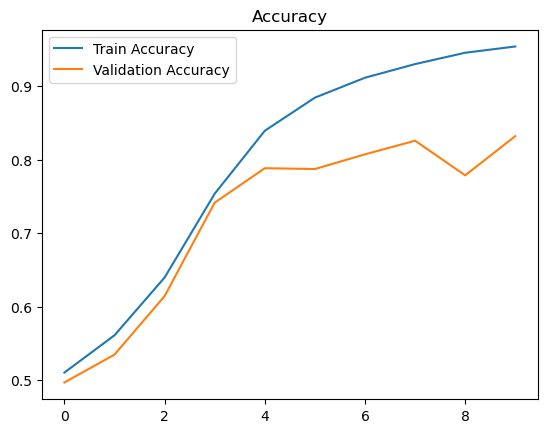

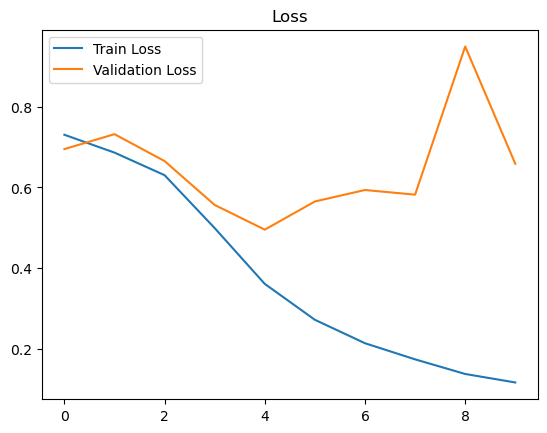

In [125]:
import matplotlib.pyplot as plt

# График точности
plt.plot(history_fcn.history['accuracy'], label='Train Accuracy')
plt.plot(history_fcn.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

# График потерь
plt.plot(history_fcn.history['loss'], label='Train Loss')
plt.plot(history_fcn.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()